In [38]:

from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langgraph.checkpoint.postgres import PostgresSaver
import os
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel,Field
from typing import List

load_dotenv(override=True)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
print(f"API Key Loaded: {bool(os.getenv('GROQ_API_KEY'))}")
# Initialize LLM with Groq API for chat responses
llm = ChatGroq(model="openai/gpt-oss-120b")
print("LLM initialized successfully!")

API Key Loaded: True
LLM initialized successfully!


In [39]:
store = InMemoryStore()

In [40]:
extractor_llm = ChatGroq(model="openai/gpt-oss-120b",temperature=0)


In [41]:
class MemoryItem(BaseModel):
    text : str = Field(description="Atomic user memories to store")
    is_new : bool = Field(description="true if the memory is NEW and should be stored , False if duplicate / already known")
    

In [42]:
class MemoryDecision(BaseModel):
    should_write : bool = Field(description="whether to store any memories")
    memories :List[MemoryItem] = Field(default_factory=list,description="Atomic user memories to store")

In [43]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [44]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate Creating and maintaining accurate user memory.
 Current user details, bracket, ( existing memories) = {user_details_content}
 
 TASK:
 - Review the user Review the user latest message.
 - Extract user-specific info worth Projects.
 - For each Extracted item set is_new =  true only, If it adds NEW information compared to current user details.
 - If it is Basically the same meaning as something As something already present, Set isNew Equals to false. Keep     each  memory as a short, atomic sentence. No speculation, Only fact. 
 - If there is nothing memory worthy, return an empty list.
 """

In [45]:
import uuid
def chat_creates_memory_nodes(state:MessagesState,config:RunnableConfig , store:BaseStore):
    user_id=config["configurable"]["user_id"]

    namespace = ("user",user_id , "details")
    #Load exiting memories
    existing_items = store.search(namespace)
    existing_texts =[it.value.get("data","") for it in existing_items if it.value.get("data")]

    user_Details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "No user details available."

#last messsage
    last_msg = state["messages"][-1]

    decision:MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(MEMORY_PROMPT.format(user_details_content=user_Details_content)),
            ),
            {"role":"user","content":f"USER MESSAGE :\n{last_msg}"},

        ]
    )

    #write to store only new memories

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace,str(uuid.uuid4()),{"data":mem.text})

#IMPORTANT : we are no using memory not evebn responding with the LLM

    return {"messages":[{"role":"assistant","content":"Noted..."}]}

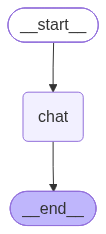

In [46]:
builder = StateGraph(MessagesState)
builder.add_node("chat",chat_creates_memory_nodes)
builder.add_edge(START,"chat")
builder.add_edge("chat",END)

graph = builder.compile(store=store)
graph


In [47]:
config = {"configurable": {"user_id":"u1"}}

In [51]:
#Demo

res = graph.invoke(
    {"messages":[{"role":"user","content":"Hi, my name is vijay pandit"}]},config)

print("Assistant : ",res["messages"][-1].content)

Assistant :  Noted...


In [49]:
#Demo
res = graph.invoke(
    {"messages":[{"role":"user","content":"Hi, I love java + AI programming"}]},config)

print("Assistant : ",res["messages"][-1].content)

Assistant :  Noted...


In [52]:
items = store.search(("user","u1","details"))
for item in items:
    print(item.value['data'])

User's name is Vijay Pandit
User loves Java programming.
User loves AI programming.


#Duplicate memory gets saved , so we have to implement de-duplication strategy 